# KEGG Ground Truth Collection
Fetch human pathway → UniProt protein set mappings from the KEGG REST API for the protein embedding benchmark.

In [1]:
import requests
import pickle
import time
from collections import defaultdict
from datetime import datetime

BASE_URL = "https://rest.kegg.jp"

def fetch_kegg(endpoint: str) -> str:
    """Fetch data from KEGG REST API with rate limiting."""
    url = f"{BASE_URL}/{endpoint}"
    print(f"Fetching: {url}")
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    time.sleep(0.35)  # KEGG asks max 3 requests/sec
    return resp.text

def parse_tsv(text: str) -> list[tuple[str, str]]:
    """Parse KEGG tab-separated two-column response."""
    pairs = []
    for line in text.strip().split("\n"):
        if not line.strip():
            continue
        parts = line.split("\t")
        if len(parts) == 2:
            pairs.append((parts[0].strip(), parts[1].strip()))
    return pairs

# 1. Fetch gene → pathway links

In [2]:
gene_pathway_text = fetch_kegg("link/pathway/hsa")
gene_pathway_links = parse_tsv(gene_pathway_text)

print(f"Total gene-pathway links: {len(gene_pathway_links)}")
print(f"\nFirst 10 entries:")
gene_pathway_links[:10]

Fetching: https://rest.kegg.jp/link/pathway/hsa
Total gene-pathway links: 39336

First 10 entries:


[('hsa:10327', 'path:hsa00010'),
 ('hsa:124', 'path:hsa00010'),
 ('hsa:125', 'path:hsa00010'),
 ('hsa:126', 'path:hsa00010'),
 ('hsa:127', 'path:hsa00010'),
 ('hsa:128', 'path:hsa00010'),
 ('hsa:130', 'path:hsa00010'),
 ('hsa:130589', 'path:hsa00010'),
 ('hsa:131', 'path:hsa00010'),
 ('hsa:160287', 'path:hsa00010')]

hsa is the KEGG organism code for Homo sapiens, and it appears in both contexts:

- hsa:10327 — a human gene entry, where 10327 is the Entrez/NCBI Gene ID. So hsa:10327 just means "human gene #10327".
- path:hsa00010 — a human-specific pathway, where hsa00010 means "the human version of KEGG reference pathway 00010 (Glycolysis / Gluconeogenesis)". The 00010 is the universal pathway number, and the hsa prefix makes it organism-specific.

# Fetch KEGG gene ID → UniProt conversion

The conv/uniprot/hsa endpoint returns the mapping between KEGG human gene IDs and UniProt accessions. The raw response looks something like:

- hsa:10327	up:Q9UBV4
- hsa:10327	up:A0A087WZP3
- hsa:124	up:P04075

We need this because the gene→pathway links from step 1 use KEGG identifiers (hsa:10327), but the protein embeddings use UniProt IDs. So this is essentially a translation table.

In [3]:
conv_text = fetch_kegg("conv/uniprot/hsa")
conv_pairs = parse_tsv(conv_text)

kegg_to_uniprot = defaultdict(set)
for kegg_id, uniprot_id in conv_pairs:
    kegg_to_uniprot[kegg_id].add(uniprot_id.replace("up:", ""))

kegg_to_uniprot = dict(kegg_to_uniprot)

print(f"KEGG genes with UniProt mapping: {len(kegg_to_uniprot)}")
print(f"Total UniProt IDs: {sum(len(v) for v in kegg_to_uniprot.values())}")
print(f"\nExample (first 5):")
for i, (k, v) in enumerate(kegg_to_uniprot.items()):
    if i >= 5: break
    print(f"  {k} → {v}")

Fetching: https://rest.kegg.jp/conv/uniprot/hsa
KEGG genes with UniProt mapping: 19413
Total UniProt IDs: 24461

Example (first 5):
  hsa:1 → {'V9HWD8', 'P04217'}
  hsa:10 → {'P11245', 'A4Z6T7'}
  hsa:100 → {'A0A0S2Z381', 'P00813'}
  hsa:1000 → {'P19022'}
  hsa:10000 → {'Q9Y243'}


# 3. Fetch pathway namnes

In [4]:
list_text = fetch_kegg("list/pathway/hsa")
list_pairs = parse_tsv(list_text)

pathway_names = {}
for path_id, name in list_pairs:
    clean_id = path_id.replace("path:", "")
    clean_name = name.split(" - Homo sapiens")[0].strip()
    pathway_names[clean_id] = clean_name

print(f"Human pathways: {len(pathway_names)}")
print(f"\nFirst 10:")
for i, (k, v) in enumerate(pathway_names.items()):
    if i >= 10: break
    print(f"  {k}: {v}")

Fetching: https://rest.kegg.jp/list/pathway/hsa
Human pathways: 370

First 10:
  hsa01100: Metabolic pathways
  hsa01200: Carbon metabolism
  hsa01210: 2-Oxocarboxylic acid metabolism
  hsa01212: Fatty acid metabolism
  hsa01230: Biosynthesis of amino acids
  hsa01232: Nucleotide metabolism
  hsa01250: Biosynthesis of nucleotide sugars
  hsa01240: Biosynthesis of cofactors
  hsa01320: Sulfur cycle
  hsa00010: Glycolysis / Gluconeogenesis


# 4. Build ground truth: pathway → set of Uniprot IDs

In [5]:
pathway_to_proteins = defaultdict(set)
unmapped_genes = set()

for kegg_gene, pathway_id in gene_pathway_links:
    clean_pathway = pathway_id.replace("path:", "")
    if kegg_gene in kegg_to_uniprot:
        for uniprot_id in kegg_to_uniprot[kegg_gene]:
            pathway_to_proteins[clean_pathway].add(uniprot_id)
    else:
        unmapped_genes.add(kegg_gene)

# Add pathway names to keys
pathway_to_proteins = {
    f"{pid} {pathway_names.get(pid, 'Unknown')}": proteins
    for pid, proteins in pathway_to_proteins.items()
}

print(f"Pathways with ≥1 protein: {len(pathway_to_proteins)}")
print(f"Unmapped KEGG genes (no UniProt): {len(unmapped_genes)}")

all_labeled_proteins = set().union(*pathway_to_proteins.values())
print(f"Unique UniProt proteins: {len(all_labeled_proteins)}")

Pathways with ≥1 protein: 370
Unmapped KEGG genes (no UniProt): 878
Unique UniProt proteins: 11163


In [6]:
pathway_to_proteins

{'hsa00010 Glycolysis / Gluconeogenesis': {'A0A024QZ64',
  'A0A024R0Y5',
  'A0A024R4F1',
  'A0A024R713',
  'A0A024R782',
  'A0A0C4DG85',
  'A0A0K0K1K1',
  'A0A140VJM9',
  'A0A140VJR3',
  'A0A140VKA7',
  'A0A384MDR8',
  'A0A384MDW6',
  'A0A384MTJ7',
  'A0A384MTT2',
  'A0A384NPN7',
  'A6NNW6',
  'A8K7J7',
  'B3KT70',
  'B3KXY9',
  'O00757',
  'O14556',
  'P00325',
  'P00326',
  'P00338',
  'P00558',
  'P04075',
  'P04406',
  'P05062',
  'P05091',
  'P06733',
  'P06744',
  'P07195',
  'P07205',
  'P07327',
  'P07738',
  'P07864',
  'P08237',
  'P08319',
  'P08559',
  'P09104',
  'P09467',
  'P09622',
  'P09972',
  'P10515',
  'P11177',
  'P11766',
  'P13929',
  'P14550',
  'P14618',
  'P15259',
  'P17858',
  'P18669',
  'P19367',
  'P28332',
  'P29803',
  'P30613',
  'P30837',
  'P30838',
  'P35557',
  'P35558',
  'P35575',
  'P36871',
  'P40394',
  'P43353',
  'P48448',
  'P49189',
  'P49419',
  'P51648',
  'P52789',
  'P52790',
  'P60174',
  'Q01813',
  'Q16822',
  'Q2TB90',
  'Q53HE2',

# 5. Evaluate how to define the labels

now with this dict we should make a ground truth dataset, but how do we define positives and negatives there are multiple options: 
- if 2 proteins at least share one pathway they are functionally associated
- we could make this requirement larger, for example 2 or 3 pathways but we should evaluate this. 
- if one of the proteins in a pair does not occur in any kegg map it gets a label NaN because we do not know
the final goal is to make a dataframe of 20K x 20K where every pair has a label for kegg: kegg_label
is this feasable?  



In [7]:
import numpy as np
import matplotlib.pyplot as plt

# How many of our 20K proteins are in KEGG?
kegg_proteins = set(pathway_to_proteins.keys())
print(f"pathways in KEGG: {len(kegg_proteins)}")
print(f"20K x 20K matrix memory (int8): {20_000 * 20_000 / 1e9:.2f} GB — very feasible")

pathways in KEGG: 370
20K x 20K matrix memory (int8): 0.40 GB — very feasible


In [8]:
# Build protein → set of pathway IDs for fast intersection
protein_to_pw_set = defaultdict(set)
for kegg_gene, pathway_id in gene_pathway_links:
    clean_pw = pathway_id.replace("path:", "")
    if kegg_gene in kegg_to_uniprot:
        for uid in kegg_to_uniprot[kegg_gene]:
            protein_to_pw_set[uid].add(clean_pw)

protein_to_pw_set = dict(protein_to_pw_set)
print(f"Proteins with pathway annotations: {len(protein_to_pw_set)}")

Proteins with pathway annotations: 11163


In [9]:
# Count shared pathways for all KEGG-annotated protein pairs
# Only need to do this for proteins that are IN kegg (both must be)
kegg_protein_list = sorted(protein_to_pw_set.keys())
n_kegg = len(kegg_protein_list)
print(f"Computing shared pathway counts for {n_kegg} KEGG proteins...")
print(f"That's {n_kegg * (n_kegg - 1) // 2:,} unique pairs")

# Vectorized approach: build a binary pathway membership matrix
# then shared pathways = dot product
all_pathways = sorted(set().union(*protein_to_pw_set.values()))
pw_to_idx = {pw: i for i, pw in enumerate(all_pathways)}

membership = np.zeros((n_kegg, len(all_pathways)), dtype=np.float32)
for i, prot in enumerate(kegg_protein_list):
    for pw in protein_to_pw_set[prot]:
        membership[i, pw_to_idx[pw]] = 1.0

print(f"Membership matrix shape: {membership.shape}")
print(f"Computing shared pathway count matrix (dot product)...")

# shared_counts[i,j] = number of pathways shared between protein i and j
shared_counts = membership @ membership.T
print(f"Done! Shape: {shared_counts.shape}")

Computing shared pathway counts for 11163 KEGG proteins...
That's 62,300,703 unique pairs
Membership matrix shape: (11163, 370)
Computing shared pathway count matrix (dot product)...
Done! Shape: (11163, 11163)


In [10]:
# Extract upper triangle (unique pairs only, exclude diagonal)
upper_tri = shared_counts[np.triu_indices(n_kegg, k=1)]
total_pairs = len(upper_tri)

print(f"Total evaluable pairs (both in KEGG): {total_pairs:,}")
print(f"Pairs sharing 0 pathways: {np.sum(upper_tri == 0):,}")
print(f"\nShared pathway count distribution:")
for i in range(int(upper_tri.max()) + 1):
    count = np.sum(upper_tri == i)
    if count > 0:
        print(f"  {i} shared pathways: {count:>10,} pairs ({count/total_pairs*100:.2f}%)")
    if count == 0 and i > 5:
        break

Total evaluable pairs (both in KEGG): 62,300,703
Pairs sharing 0 pathways: 56,661,538

Shared pathway count distribution:
  0 shared pathways: 56,661,538 pairs (90.95%)
  1 shared pathways:  4,540,534 pairs (7.29%)
  2 shared pathways:    596,175 pairs (0.96%)
  3 shared pathways:    207,329 pairs (0.33%)
  4 shared pathways:     97,031 pairs (0.16%)
  5 shared pathways:     52,560 pairs (0.08%)
  6 shared pathways:     46,999 pairs (0.08%)
  7 shared pathways:     19,625 pairs (0.03%)
  8 shared pathways:     14,010 pairs (0.02%)
  9 shared pathways:     10,473 pairs (0.02%)
  10 shared pathways:      7,762 pairs (0.01%)
  11 shared pathways:      9,872 pairs (0.02%)
  12 shared pathways:      7,892 pairs (0.01%)
  13 shared pathways:      5,835 pairs (0.01%)
  14 shared pathways:      2,624 pairs (0.00%)
  15 shared pathways:      2,292 pairs (0.00%)
  16 shared pathways:      2,386 pairs (0.00%)
  17 shared pathways:      1,987 pairs (0.00%)
  18 shared pathways:      1,614 pairs (0

most proteins that share a pathway only share one

In [11]:
# explore different thresholds for 'positive' label
thresholds = [1, 2, 3, 4]

# Assuming 20K total proteins
n_total = 20_000
n_not_in_kegg = n_total - n_kegg
total_possible_pairs = n_total * (n_total - 1) // 2

# NaN pairs: at least one protein not in KEGG
# = total_pairs - pairs_where_both_in_kegg
both_in_kegg = n_kegg * (n_kegg - 1) // 2
nan_pairs = total_possible_pairs - both_in_kegg

results = {}

for threshold in thresholds:
    n_positive = int(np.sum(upper_tri >= threshold))
    n_negative = int(both_in_kegg - n_positive)
    
    results[threshold] = {
        "positive": n_positive,
        "negative": n_negative,
        "nan": nan_pairs,
    }

In [12]:
# Summary table
print(f"{'Threshold':<12} {'Positive':>12} {'Negative':>12} {'NaN':>12} {'Pos/Neg ratio':>14}")
print("-" * 65)
for t, r in results.items():
    ratio = r['positive'] / r['negative'] if r['negative'] > 0 else float('inf')
    print(f"≥ {t} pathway{'s' if t > 1 else ' ':<7} {r['positive']:>12,} {r['negative']:>12,} {r['nan']:>12,} {ratio:>14.6f}")

Threshold        Positive     Negative          NaN  Pos/Neg ratio
-----------------------------------------------------------------
≥ 1 pathway           5,639,165   56,661,538  137,689,297       0.099524
≥ 2 pathways          1,098,631   61,202,072  137,689,297       0.017951
≥ 3 pathways            502,456   61,798,247  137,689,297       0.008131
≥ 4 pathways            295,127   62,005,576  137,689,297       0.004760


threshold >= 1 looks good

# 6. build the ground truth matrix 

- `1` = positive (share ≥ 1 pathway, both in KEGG)
- `0` = negative (share 0 pathways, both in KEGG)
- `NaN` = at least one protein not in any KEGG pathway

proteins will be ordered in alphabetical order of their protein accessions. 

## 6.1 Load the protein accessions of all proteins in the human proteome

In [13]:
fasta_path = '/home/sander/apps/prot_GPT/fasta/human_proteome_canonical_31032022.fasta'

# read fasta into a dictionary of {protein_id: sequence}, do thsi with biopython
from Bio import SeqIO
protein_sequences = {}
for record in SeqIO.parse(fasta_path, 'fasta'):
    protein_id = record.id.split('|')[1]  # extract the protein ID from the FASTA header
    sequence = str(record.seq)
    protein_sequences[protein_id] = sequence

# make a list of only the protein accessions
all_proteins = [protein_id for protein_id in protein_sequences.keys()]
all_proteins[:10]

['Q00266',
 'Q8NB16',
 'O94851',
 'Q8TDZ2',
 'Q9NPJ6',
 'Q8N635',
 'O15553',
 'Q8NCK7',
 'Q9HD23',
 'Q9NYP9']

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# all_proteins should be your full 20K protein vocabulary
# For now, we collect all UniProt IDs seen in the KEGG conversion table
all_proteins_sorted = sorted(all_proteins)  # alphabetically sorted
n = len(all_proteins_sorted)
prot_to_idx = {p: i for i, p in enumerate(all_proteins_sorted)}

print(f"Total proteins: {n}")
print(f"Matrix shape: {n} x {n}")
print(f"First 10: {all_proteins_sorted[:10]}")
print(f"Last 10:  {all_proteins_sorted[-10:]}")

Total proteins: 20372
Matrix shape: 20372 x 20372
First 10: ['A0A024RBG1', 'A0A075B6H7', 'A0A075B6H8', 'A0A075B6H9', 'A0A075B6I0', 'A0A075B6I1', 'A0A075B6I3', 'A0A075B6I4', 'A0A075B6I6', 'A0A075B6I7']
Last 10:  ['Q9Y6Z4', 'Q9Y6Z5', 'Q9Y6Z7', 'Q9YNA8', 'S4R3P1', 'S4R3Y5', 'U3KPV4', 'W5XKT8', 'W6CW81', 'X6R8D5']


## 6.2 build the matrix

In [15]:
kegg_matrix = np.full((n, n), np.nan, dtype=np.float32)

# Get indices of proteins that ARE in KEGG
kegg_indices = [prot_to_idx[p] for p in all_proteins_sorted if p in protein_to_pw_set]
kegg_indices = np.array(kegg_indices)

print(f"Proteins in KEGG: {len(kegg_indices)} / {n}")

# For all pairs where BOTH are in KEGG: set to 0 (negative by default)
# Using np.ix_ to set the submatrix
kegg_matrix[np.ix_(kegg_indices, kegg_indices)] = 0.0

print("Set all KEGG×KEGG pairs to 0 (negative)")

Proteins in KEGG: 8370 / 20372
Set all KEGG×KEGG pairs to 0 (negative)


we lose about 2.8K proteins, I looked into this:
- not because of isoforms
- because of TrEMBL unreviewed accessions in KEGG, our fasta is reviewed only. 

In [16]:
# Now set positives: pairs sharing ≥ 1 pathway
# Reuse the membership matrix approach but indexed into the full matrix

# Filter to only KEGG proteins that are in our FASTA vocabulary
kegg_protein_list_sorted = sorted([p for p in protein_to_pw_set.keys() if p in prot_to_idx])
print(f"KEGG proteins in our vocabulary: {len(kegg_protein_list_sorted)}")
all_pathways_sorted = sorted(set().union(*protein_to_pw_set.values()))
pw_to_pidx = {pw: i for i, pw in enumerate(all_pathways_sorted)}

# Build membership matrix for KEGG proteins only
membership = np.zeros((len(kegg_protein_list_sorted), len(all_pathways_sorted)), dtype=np.float32)
for i, prot in enumerate(kegg_protein_list_sorted):
    for pw in protein_to_pw_set[prot]:
        membership[i, pw_to_pidx[pw]] = 1.0

# Shared pathway counts among KEGG proteins
shared = membership @ membership.T

# Map KEGG protein indices to full matrix indices
kegg_full_indices = np.array([prot_to_idx[p] for p in kegg_protein_list_sorted])

# Set positives where shared ≥ 1
pos_i, pos_j = np.where(shared >= 1)
# Exclude diagonal
mask = pos_i != pos_j
pos_i, pos_j = pos_i[mask], pos_j[mask]

kegg_matrix[kegg_full_indices[pos_i], kegg_full_indices[pos_j]] = 1.0

print(f"Set {len(pos_i):,} positive entries (both directions)")

KEGG proteins in our vocabulary: 8370
Set 5,821,002 positive entries (both directions)


In [17]:
# Set diagonal to NaN (a protein paired with itself is not meaningful)
np.fill_diagonal(kegg_matrix, np.nan)

# Verify counts (upper triangle only)
upper = kegg_matrix[np.triu_indices(n, k=1)]
n_pos = np.nansum(upper == 1)
n_neg = np.nansum(upper == 0)
n_nan = np.sum(np.isnan(upper))

print(f"Upper triangle counts:")
print(f"  Positive (1): {int(n_pos):>12,}")
print(f"  Negative (0): {int(n_neg):>12,}")
print(f"  NaN:          {int(n_nan):>12,}")
print(f"  Total:        {len(upper):>12,}")
print(f"\n  Pos/Neg ratio: {n_pos/n_neg:.6f}")
print(f"  Matrix is symmetric: {np.allclose(kegg_matrix, kegg_matrix.T, equal_nan=True)}")

Upper triangle counts:
  Positive (1):    2,910,501
  Negative (0):   32,113,764
  NaN:           172,474,741
  Total:         207,499,006

  Pos/Neg ratio: 0.090631
  Matrix is symmetric: True


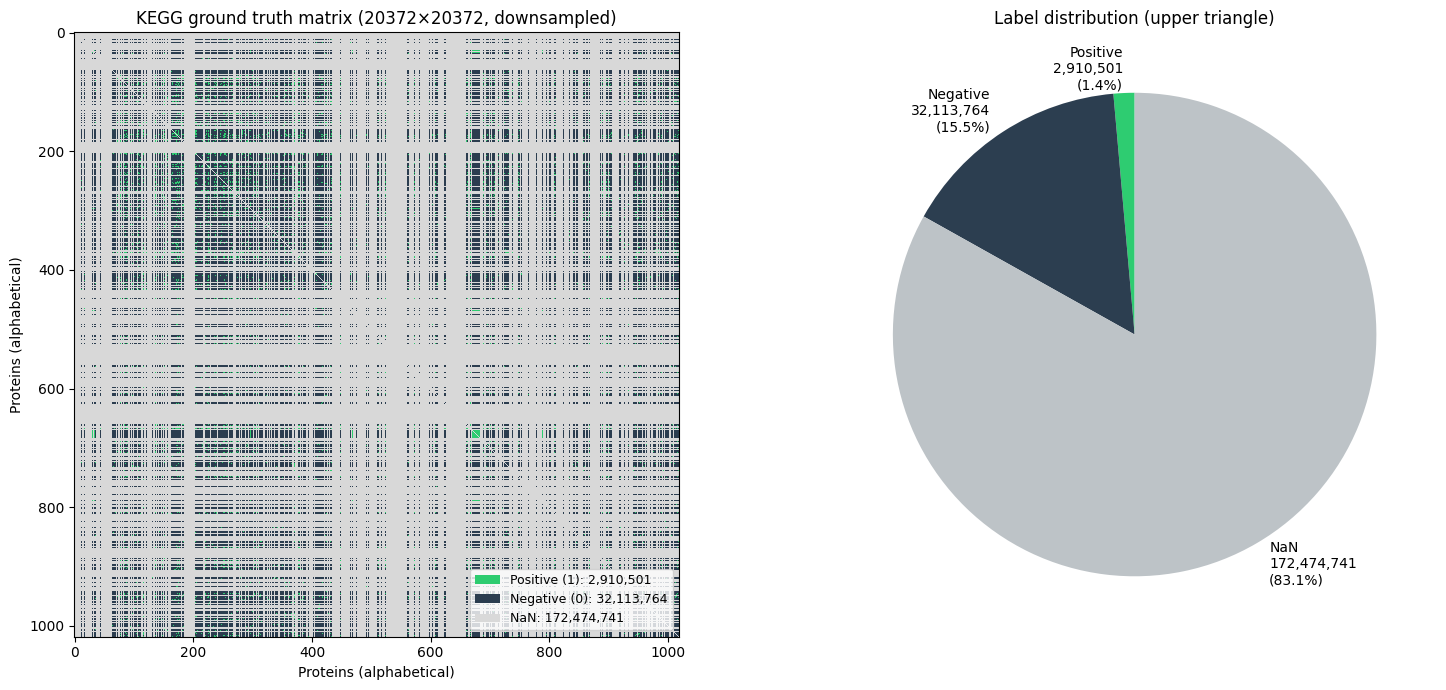

In [18]:
# Visualize the matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: full matrix (downsampled for visualization)
step = max(1, n // 1000)  # downsample to ~1000x1000 for plotting
display_matrix = kegg_matrix[::step, ::step]

# Create a 3-color image: NaN=grey, 0=dark, 1=bright
rgb = np.zeros((*display_matrix.shape, 3), dtype=np.float32)
nan_mask = np.isnan(display_matrix)
neg_mask = display_matrix == 0
pos_mask = display_matrix == 1

# NaN = light grey
rgb[nan_mask] = [0.85, 0.85, 0.85]
# Negative = dark blue
rgb[neg_mask] = [0.17, 0.24, 0.31]
# Positive = green
rgb[pos_mask] = [0.18, 0.80, 0.44]

axes[0].imshow(rgb, aspect='equal', interpolation='nearest')
axes[0].set_title(f"KEGG ground truth matrix ({n}×{n}, downsampled)", fontsize=12)
axes[0].set_xlabel("Proteins (alphabetical)")
axes[0].set_ylabel("Proteins (alphabetical)")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=[0.18, 0.80, 0.44], label=f'Positive (1): {int(n_pos):,}'),
    Patch(facecolor=[0.17, 0.24, 0.31], label=f'Negative (0): {int(n_neg):,}'),
    Patch(facecolor=[0.85, 0.85, 0.85], label=f'NaN: {int(n_nan):,}'),
]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=9)

# Right: pie chart of label distribution
sizes = [int(n_pos), int(n_neg), int(n_nan)]
labels = [f'Positive\n{int(n_pos):,}\n({n_pos/len(upper)*100:.1f}%)',
          f'Negative\n{int(n_neg):,}\n({n_neg/len(upper)*100:.1f}%)',
          f'NaN\n{int(n_nan):,}\n({n_nan/len(upper)*100:.1f}%)']
colors = ['#2ecc71', '#2c3e50', '#bdc3c7']

axes[1].pie(sizes, labels=labels, colors=colors, startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Label distribution (upper triangle)', fontsize=12)

plt.tight_layout()
plt.show()

this makes total sense, with 8000 out of the 20 000 proteins not being present we would expect most pairs to be NaN. 

In [19]:
from pathlib import Path
from omicsfm.attention import GT_DIR_DEFAULT, save_ppi_ground_truth

# save_ppi_ground_truth stores only the positives and the covered-protein
# universe (~36x smaller, reconstructs the dense matrix exactly) and will
# not replace an existing file: published results are pinned to the
# matrices in reference/, and these source databases change over time.
# Save matrix as .npz and protein list as .tsv
save_ppi_ground_truth(
    path=Path(GT_DIR_DEFAULT) / "kegg_ground_truth_matrix.npz",
    matrix=kegg_matrix,
    overwrite=False,   # True re-pins the published matrix; every result
                       # and figure derived from it must be regenerated too
) float32, values: 0, 1, NaN
)

# Save protein order as plain text (one per line)
with open("kegg_ground_truth_proteins.tsv", "w") as f:
    f.write("idx\tprotein\n")
    for i, p in enumerate(all_proteins_sorted):
        f.write(f"{i}\t{p}\n")

import os
npz_size = os.path.getsize("kegg_ground_truth_matrix.npz") / 1e6
print(f"Saved kegg_ground_truth_matrix.npz ({npz_size:.1f} MB)")
print(f"Saved kegg_ground_truth_proteins.tsv")

print(f"\nTo load later:")
print(f"  matrix = np.load('kegg_ground_truth_matrix.npz')['matrix']")
print(f"  proteins = pd.read_csv('kegg_ground_truth_proteins.tsv', sep='\\t')['protein'].tolist()")

Saved kegg_ground_truth_matrix.npz (45.4 MB)
Saved kegg_ground_truth_proteins.tsv

To load later:
  matrix = np.load('kegg_ground_truth_matrix.npz')['matrix']
  proteins = pd.read_csv('kegg_ground_truth_proteins.tsv', sep='\t')['protein'].tolist()
